## Insurance Cost Prediction Model

Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap
import pickle
from feature_engine.outliers import ArbitraryOutlierCapper

Loading Data from Hugging Face

In [3]:
# Loading dataset from Hugging Face
df = pd.read_csv("hf://datasets/adegoke655/Insurance/insurance.csv")

# Saving locally for reproducibility
df.to_csv("insurance_data.csv", index=False)

print("Dataset saved successfully as insurance_data.csv")
print(f"Dataset shape: {df.shape}")

Dataset saved successfully as insurance_data.csv
Dataset shape: (1338, 7)


Understanding the Data

In [4]:
# Viewing the first 5 rows
insurance_data = pd.read_csv("insurance_data.csv")
print(insurance_data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
# Dataset information
insurance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [7]:
# Statistical summary of the data
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Performing Exploratory Data Analysis (EDA)

Check Missing Values

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Categorical Feature Distributions

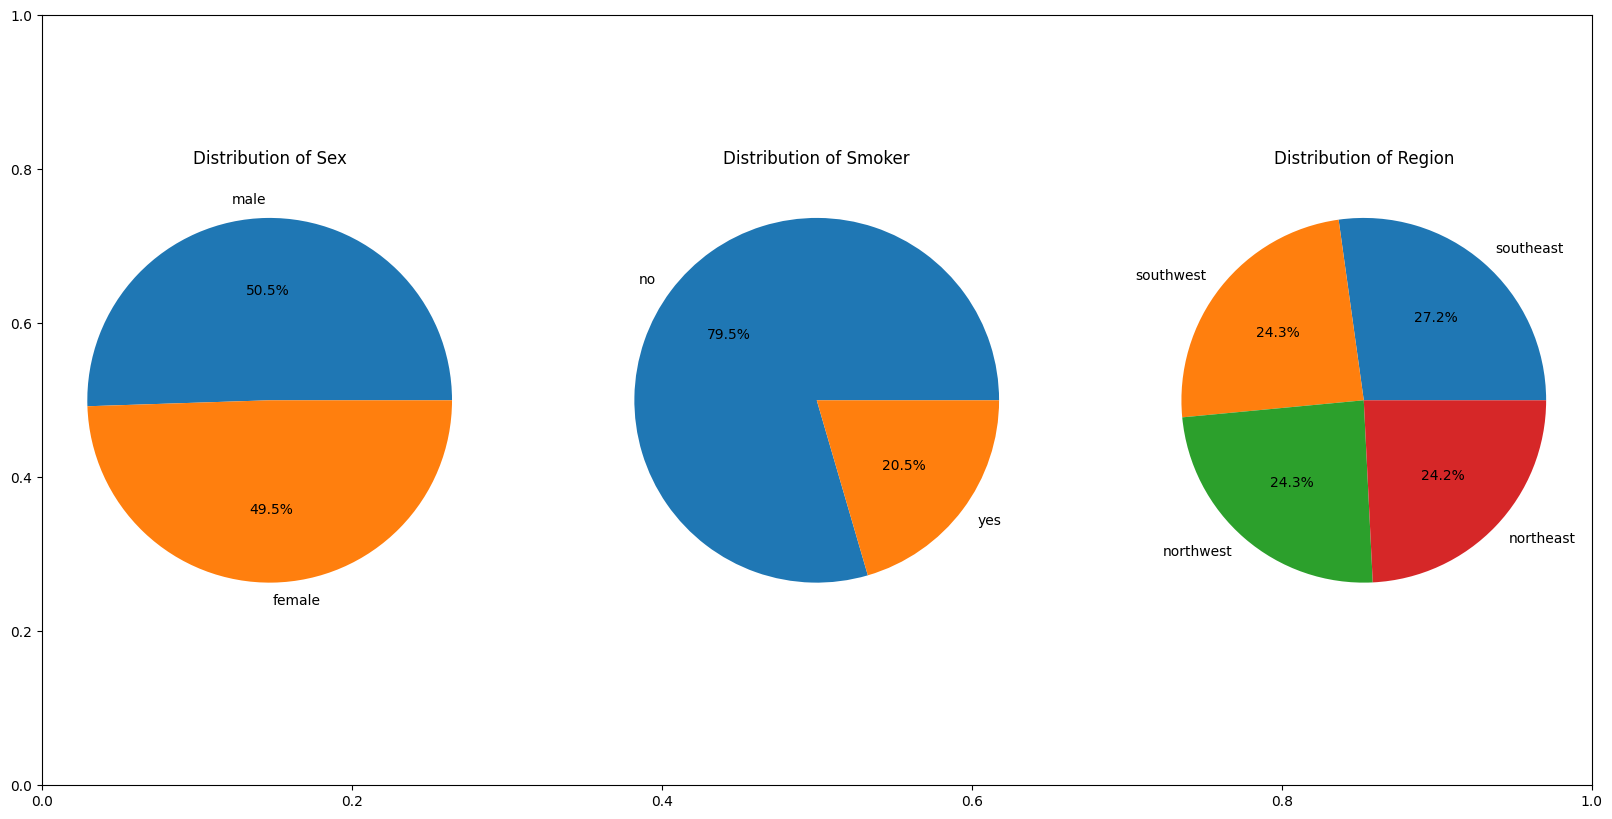

In [15]:
features = ['sex', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.title(f'Distribution of {col.capitalize()}')
    x = df[col].value_counts()
    plt.pie(x.values, labels=x.index, autopct='%1.1f%%')

plt.show()

Key Insights                                                       
Males pay slightly more than females (minimal difference)                              
Smokers pay approximately 3× more than non-smokers

Average Charges by Category

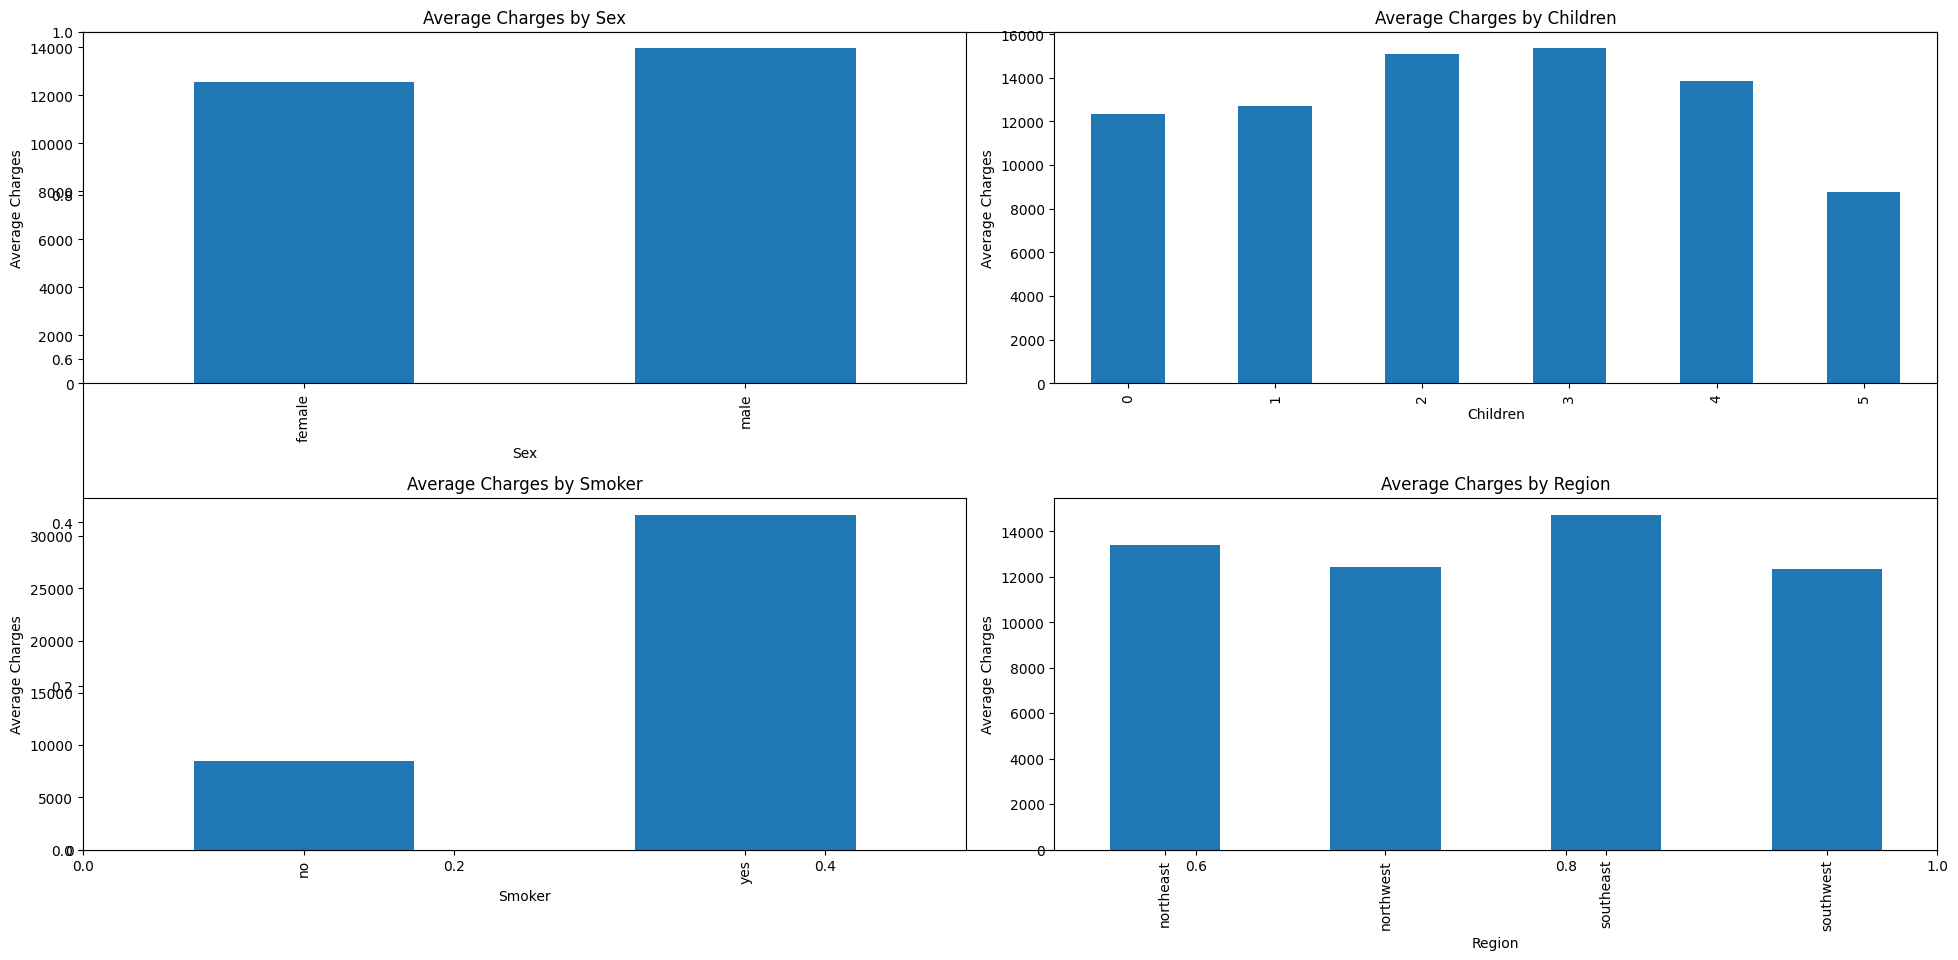

In [12]:
features = ['sex', 'children', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col)['charges'].mean().astype(float).plot.bar()
    plt.title(f'Average Charges by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Average Charges')
plt.tight_layout()
plt.show()

Numerical Features vs Charges

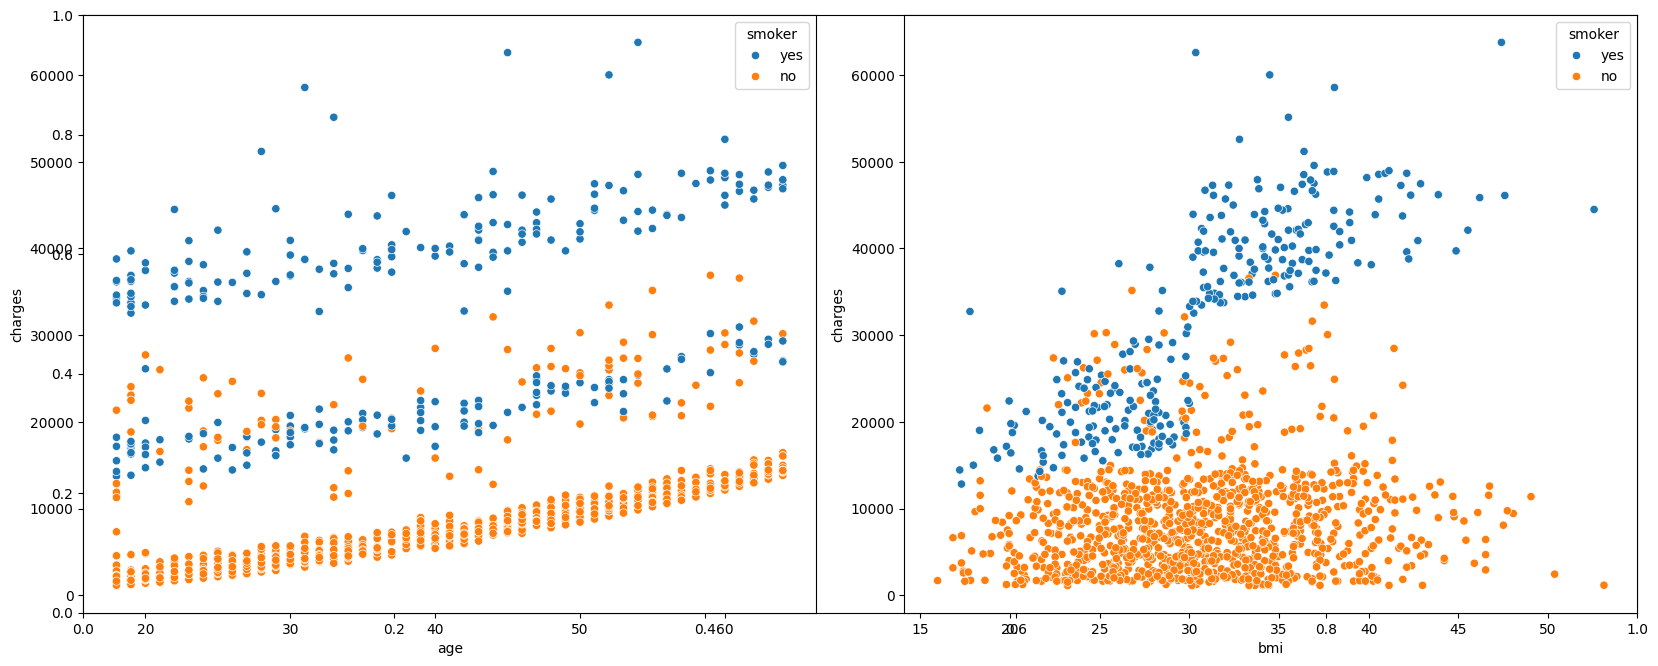

In [16]:
features = ['age', 'bmi']

plt.subplots(figsize=(17, 7))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker')
plt.tight_layout()
plt.show()

Clear separation between smokers and non-smokers in both age and BMI relationships

Carrying out Data Preprocessing

Handling Duplicates

In [17]:
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

df.drop_duplicates(inplace=True)
print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 1
Duplicates removed. New shape: (1337, 7)


Outlier Detection - Age

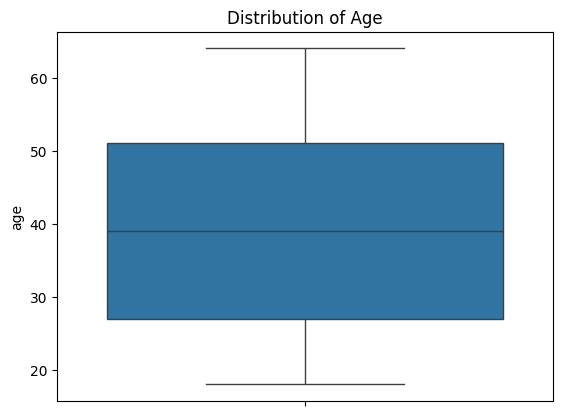

In [19]:
sns.boxplot(df['age'])
plt.title('Distribution of Age')
plt.show()

No outliers detected in age distribution

Outlier Detection and Treatment in the BMI

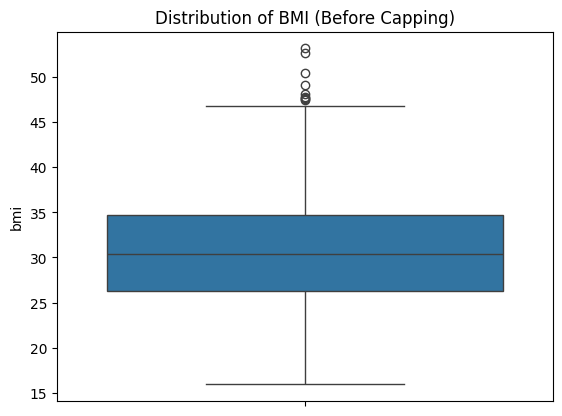

In [21]:
# Initial boxplot
sns.boxplot(df['bmi'])
plt.title('Distribution of BMI (Before Capping)')
plt.show()

outliers detected

In [22]:
# Calculating the IQR bounds
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"IQR Bounds: [{lower_limit:.4f}, {upper_limit:.4f}]")

IQR Bounds: [13.6750, 47.3150]


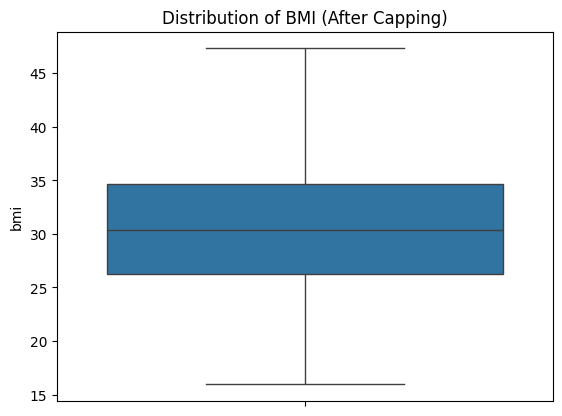

In [24]:
# Capping outliers using feature-engine
arb = ArbitraryOutlierCapper(
    min_capping_dict={'bmi': lower_limit},
    max_capping_dict={'bmi': upper_limit}
)
df[['bmi']] = arb.fit_transform(df[['bmi']])

# Verifying outlier treatment using aboxplot
sns.boxplot(df['bmi'])
plt.title('Distribution of BMI (After Capping)')
plt.show()

Outliers successfully treated in BMI column

Performing Data Wrangling(Encoding)

In [25]:
# Checking skewness
print(f"BMI Skewness: {df['bmi'].skew():.4f}")
print(f"Age Skewness: {df['age'].skew():.4f}")

BMI Skewness: 0.2329
Age Skewness: 0.0548


In [26]:
# Encoding categorical features for abetter 
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['region'] = df['region'].map({
    'northwest': 0, 
    'northeast': 1,
    'southeast': 2,
    'southwest': 3
})

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


In [27]:
# Correlation matrix
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.019814,0.111998,0.041536,-0.025587,0.001771,0.298308
sex,0.019814,1.000000,-0.044831,-0.017848,-0.076596,-0.008998,-0.058044
bmi,0.111998,-0.044831,1.000000,0.013692,0.003151,0.156937,0.199063
children,0.041536,-0.017848,0.013692,1.000000,0.007331,-0.002842,0.067389
smoker,-0.025587,-0.076596,0.003151,0.007331,1.000000,0.012736,0.787234
region,0.001771,-0.008998,0.156937,-0.002842,0.012736,1.000000,0.010767
charges,0.298308,-0.058044,0.199063,0.067389,0.787234,0.010767,1.000000


---

Model Development using Traditional Machine Learning

In [28]:
# Preparing features and target
X = df.drop(['charges'], axis=1)
Y = df[['charges']]

# Train-test split
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set: {xtrain.shape[0]} samples")
print(f"Test set: {xtest.shape[0]} samples")

Training set: 1069 samples
Test set: 268 samples


Linear Regression

In [29]:
lrmodel = LinearRegression()
lrmodel.fit(xtrain, ytrain)

lr_train_r2 = lrmodel.score(xtrain, ytrain)
lr_test_r2 = lrmodel.score(xtest, ytest)
lr_cv = cross_val_score(lrmodel, X, Y, cv=5).mean()

print(f"Linear Regression Results:")
print(f"Train R²: {lr_train_r2:.4f}")
print(f"Test R²: {lr_test_r2:.4f}")
print(f"CV Score: {lr_cv:.4f}")

Linear Regression Results:
Train R²: 0.7295
Test R²: 0.8062
CV Score: 0.7471


Support Vector Regressor

In [31]:
svrmodel = SVR()
svrmodel.fit(xtrain, ytrain)

svr_train_r2 = r2_score(ytrain, svrmodel.predict(xtrain))
svr_test_r2 = r2_score(ytest, svrmodel.predict(xtest))
svr_cv = cross_val_score(svrmodel, X, Y, cv=5).mean()

print(f"SVR Results:")
print(f"Train R²: {svr_train_r2:.4f}")
print(f"Test R²: {svr_test_r2:.4f}")
print(f"CV Score: {svr_cv:.4f}")

SVR Results:
Train R²: -0.1015
Test R²: -0.1344
CV Score: -0.1037


Random Forest Regressor

In [32]:
# Baseline Random Forest
rfmodel = RandomForestRegressor(random_state=42)
rfmodel.fit(xtrain, ytrain)

print("Baseline Random Forest:")
print(f"Train R²: {r2_score(ytrain, rfmodel.predict(xtrain)):.4f}")
print(f"Test R²: {r2_score(ytest, rfmodel.predict(xtest)):.4f}")
print(f"CV Score: {cross_val_score(rfmodel, X, Y, cv=5).mean():.4f}")

Baseline Random Forest:
Train R²: 0.9738
Test R²: 0.8819
CV Score: 0.8364
CV Score: 0.8364


In [33]:
# Hyperparameter tuning
param_grid = {'n_estimators': [10, 40, 50, 98, 100, 120, 150]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, scoring="r2", cv=5)
grid_rf.fit(xtrain, ytrain)

print(f"Best Parameters: {grid_rf.best_params_}")

Best Parameters: {'n_estimators': 120}


In [34]:
# Final Random Forest
rfmodel = RandomForestRegressor(random_state=42, n_estimators=120)
rfmodel.fit(xtrain, ytrain)

rf_train_r2 = r2_score(ytrain, rfmodel.predict(xtrain))
rf_test_r2 = r2_score(ytest, rfmodel.predict(xtest))
rf_cv = cross_val_score(rfmodel, X, Y, cv=5).mean()

print(f"Final Random Forest Results:")
print(f"Train R²: {rf_train_r2:.4f}")
print(f"Test R²: {rf_test_r2:.4f}")
print(f"CV Score: {rf_cv:.4f}")

Final Random Forest Results:
Train R²: 0.9746
Test R²: 0.8822
CV Score: 0.8367


Gradient Boosting Regressor

In [35]:
# Baseline Gradient Boosting
gbmodel = GradientBoostingRegressor()
gbmodel.fit(xtrain, ytrain)

print("Baseline Gradient Boosting:")
print(f"Train R²: {r2_score(ytrain, gbmodel.predict(xtrain)):.4f}")
print(f"Test R²: {r2_score(ytest, gbmodel.predict(xtest)):.4f}")
print(f"CV Score: {cross_val_score(gbmodel, X, Y, cv=5).mean():.4f}")

Baseline Gradient Boosting:
Train R²: 0.8931
Test R²: 0.9043
CV Score: 0.8550
CV Score: 0.8550


In [36]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [10, 15, 19, 20, 21, 50],
    'learning_rate': [0.1, 0.19, 0.2, 0.21, 0.8, 1]
}
grid_gb = GridSearchCV(GradientBoostingRegressor(), param_grid, scoring="r2", cv=5)
grid_gb.fit(xtrain, ytrain)

print(f"Best Parameters: {grid_gb.best_params_}")

Best Parameters: {'learning_rate': 0.2, 'n_estimators': 20}


In [37]:
# Final Gradient Boosting
gbmodel = GradientBoostingRegressor(n_estimators=19, learning_rate=0.2)
gbmodel.fit(xtrain, ytrain)

gb_train_r2 = r2_score(ytrain, gbmodel.predict(xtrain))
gb_test_r2 = r2_score(ytest, gbmodel.predict(xtest))
gb_cv = cross_val_score(gbmodel, X, Y, cv=5).mean()

print(f"Final Gradient Boosting Results:")
print(f"Train R²: {gb_train_r2:.4f}")
print(f"Test R²: {gb_test_r2:.4f}")
print(f"CV Score: {gb_cv:.4f}")

Final Gradient Boosting Results:
Train R²: 0.8682
Test R²: 0.9017
CV Score: 0.8606


XGBoost Regressor

In [39]:
# Baseline XGBoost
xgmodel = XGBRegressor()
xgmodel.fit(xtrain, ytrain)

print("Baseline XGBoost:")
print(f"Train R²: {r2_score(ytrain, xgmodel.predict(xtrain)):.4f}")
print(f"Test R²: {r2_score(ytest, xgmodel.predict(xtest)):.4f}")
print(f"CV Score: {cross_val_score(xgmodel, X, Y, cv=5).mean():.4f}")

Baseline XGBoost:
Train R²: 0.9954
Test R²: 0.8549
CV Score: 0.8081
CV Score: 0.8081


In [40]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [10, 15, 20, 40, 50],
    'max_depth': [3, 4, 5],
    'gamma': [0, 0.15, 0.3, 0.5, 1]
}
grid_xgb = GridSearchCV(XGBRegressor(), param_grid, scoring="r2", cv=5)
grid_xgb.fit(xtrain, ytrain)

print(f"Best Parameters: {grid_xgb.best_params_}")

Best Parameters: {'gamma': 0, 'max_depth': 3, 'n_estimators': 10}


In [41]:
# Final XGBoost
xgmodel = XGBRegressor(n_estimators=15, max_depth=3, gamma=0)
xgmodel.fit(xtrain, ytrain)

xgb_train_r2 = r2_score(ytrain, xgmodel.predict(xtrain))
xgb_test_r2 = r2_score(ytest, xgmodel.predict(xtest))
xgb_cv = cross_val_score(xgmodel, X, Y, cv=5).mean()

print(f"Final XGBoost Results:")
print(f"Train R²: {xgb_train_r2:.4f}")
print(f"Test R²: {xgb_test_r2:.4f}")
print(f"CV Score: {xgb_cv:.4f}")

Final XGBoost Results:
Train R²: 0.8693
Test R²: 0.9022
CV Score: 0.8607


Model Development using Deep Learning

Feature Scaling

In [42]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

print("✅ Features scaled using StandardScaler")
print(f"Scaled training set shape: {xtrain_scaled.shape}")

✅ Features scaled using StandardScaler
Scaled training set shape: (1069, 6)


Building Deep Neural Network Architecture

In [44]:
dnn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(xtrain_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

Training Deep Learning Model

In [45]:
history = dnn_model.fit(
    xtrain_scaled, ytrain,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 307341984.0000 - mae: 13135.4482 - val_loss: 304034912.0000 - val_mae: 12605.6123
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 307341984.0000 - mae: 13135.4482 - val_loss: 304034912.0000 - val_mae: 12605.6123
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307286144.0000 - mae: 13133.5928 - val_loss: 303967008.0000 - val_mae: 12603.2227
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307286144.0000 - mae: 13133.5928 - val_loss: 303967008.0000 - val_mae: 12603.2227
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307186464.0000 - mae: 13130.2646 - val_loss: 303840448.0000 - val_mae: 12598.8936
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307186464.0000 - mae: 13130.2646 - val_loss: 303840448.0000 - val_mae: 12598.8936
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307016096.0000 - mae: 13124.5273 - val_loss: 303619008.0000 - val_mae: 12591.6240
Epoch 5/100

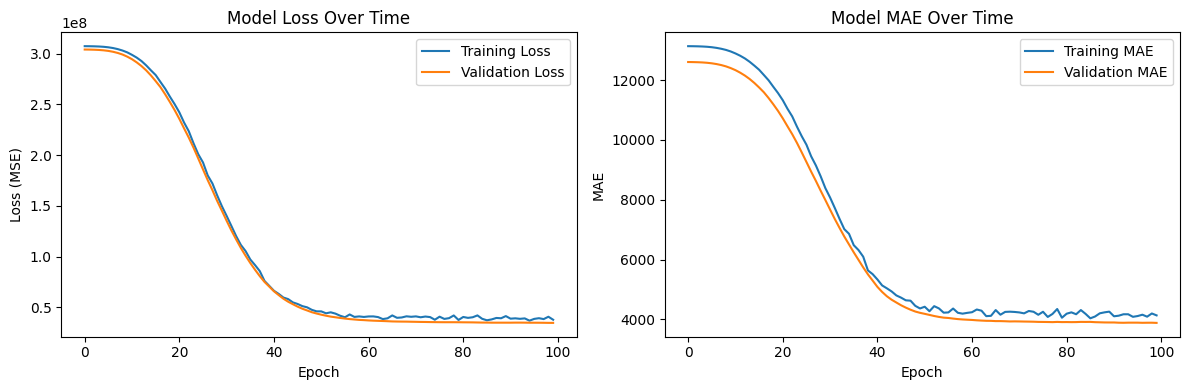

In [46]:
# Plotting training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Model Loss Over Time')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Model MAE Over Time')

plt.tight_layout()
plt.show()

Evaluate Deep Learning Model

In [47]:
dnn_predictions = dnn_model.predict(xtest_scaled)

dnn_train_pred = dnn_model.predict(xtrain_scaled)
dnn_train_r2 = r2_score(ytrain, dnn_train_pred)
dnn_test_r2 = r2_score(ytest, dnn_predictions)
dnn_mae = mean_absolute_error(ytest, dnn_predictions)

print(f"Deep Learning Model Results:")
print(f"Train R²: {dnn_train_r2:.4f}")
print(f"Test R²: {dnn_test_r2:.4f}")
print(f"Test MAE: ${dnn_mae:.2f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Deep Learning Model Results:
Train R²: 0.7467
Test R²: 0.8159
Test MAE: $3980.86
Deep Learning Model Results:
Train R²: 0.7467
Test R²: 0.8159
Test MAE: $3980.86


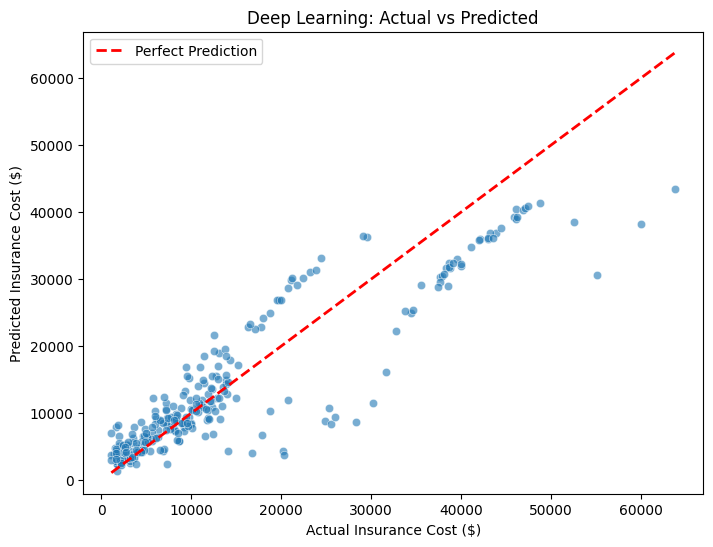

In [48]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(ytest, dnn_predictions, alpha=0.6, edgecolors='w', linewidth=0.5)
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Insurance Cost ($)')
plt.ylabel('Predicted Insurance Cost ($)')
plt.title('Deep Learning: Actual vs Predicted')
plt.legend()
plt.show()

Model Comparison

In [49]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Support Vector Regressor',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Deep Neural Network'
    ],
    'Train R²': [lr_train_r2, svr_train_r2, rf_train_r2, gb_train_r2, xgb_train_r2, dnn_train_r2],
    'Test R²': [lr_test_r2, svr_test_r2, rf_test_r2, gb_test_r2, xgb_test_r2, dnn_test_r2],
    'CV Score': [lr_cv, svr_cv, rf_cv, gb_cv, xgb_cv, 'N/A']
})

comparison_df

,Model,Train R²,Test R²,CV Score
0,Linear Regression,0.729542,0.806239,0.74707
1,Support Vector Regressor,-0.101515,-0.134445,-0.103746
2,Random Forest,0.974638,0.882201,0.836744
3,Gradient Boosting,0.868240,0.901711,0.860604
4,XGBoost,0.869317,0.902246,0.860712
5,Deep Neural Network,0.746747,0.815905,N/A


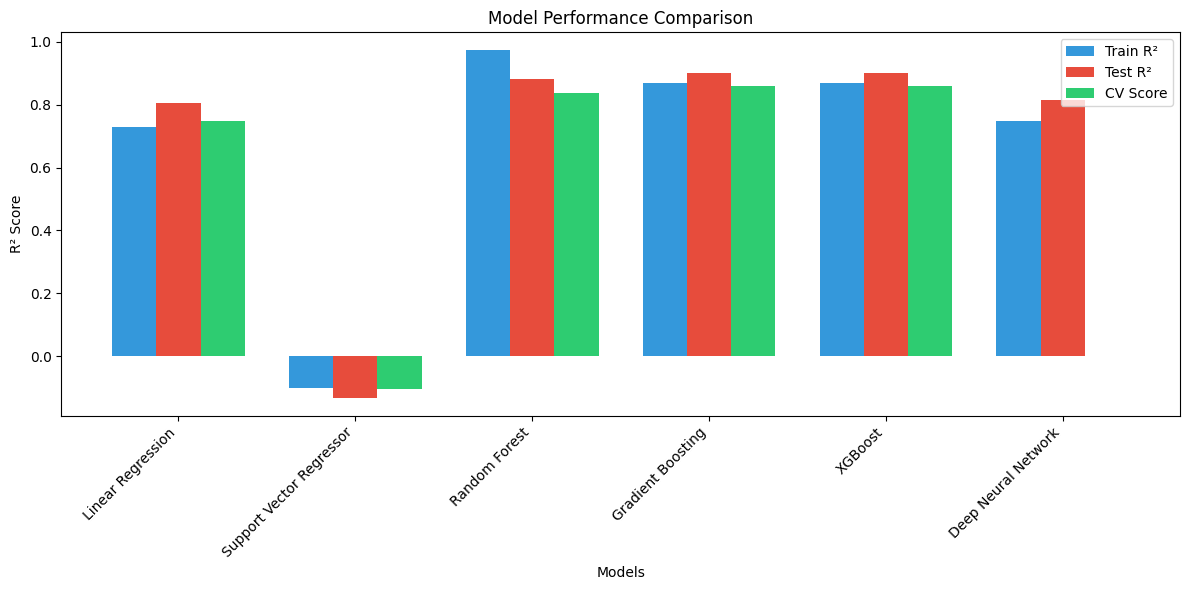

In [51]:
# Visual comparison
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.25

plt.bar(x - width, comparison_df['Train R²'], width, label='Train R²', color='#3498db')
plt.bar(x, comparison_df['Test R²'], width, label='Test R²', color='#e74c3c')
plt.bar(x + width, comparison_df['CV Score'].replace('N/A', 0).astype(float), width, label='CV Score', color='#2ecc71')

plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

XGBoost achieved the highest R2

Model Selection Rationale

**Why XGBoost over Deep Learning?**
1. **Higher Accuracy**: XGBoost (0.902) > DNN (0.816) for R2
2. **Training Speed**: XGBoost trains in seconds; DNN requires 100 epochs
**Conclusion**: XGBoost is selected as the champion model for production deployment.

Feature Selection

In [53]:
# Extract feature importance from XGBoost
feats = pd.DataFrame(
    data=grid_xgb.best_estimator_.feature_importances_,
    index=X.columns,
    columns=['Importance']
)
feats

,Importance
age,0.038633
sex,0.000000
bmi,0.133449
children,0.011073
smoker,0.809626
region,0.007219


In [54]:
# Filtering important features (importance > 0.01)
important_features = feats[feats['Importance'] > 0.01]
print("Important Features (Importance > 0.01):")
print(important_features)

Important Features (Importance > 0.01):
          Importance
age         0.038633
bmi         0.133449
children    0.011073
smoker      0.809626


<Figure size 800x500 with 0 Axes>

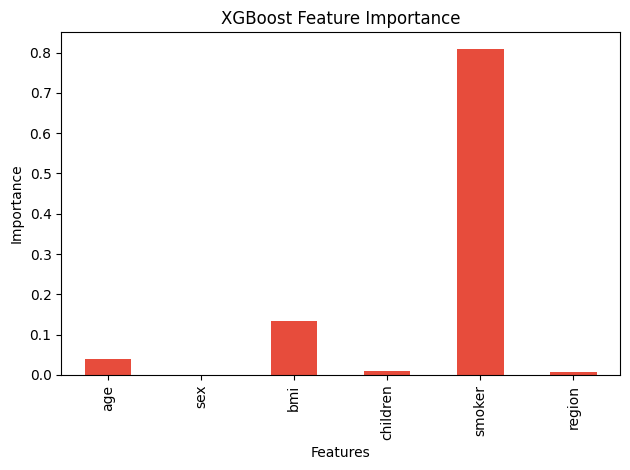

In [56]:
# Visualizing feature importance
plt.figure(figsize=(8, 5))
feats.plot(kind='bar', legend=False, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'])
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [58]:
# Dropping less-essential features
df_final = df.drop(['sex', 'region'], axis=1)

Xf = df_final.drop(['charges'], axis=1)
Yf = df_final[['charges']]

# Retraining test split with selected features
xtrain_f, xtest_f, ytrain_f, ytest_f = train_test_split(Xf, Yf, test_size=0.2, random_state=42)

print(f"Final features: {list(Xf.columns)}")
print(f"Training set: {xtrain_f.shape[0]} samples")
print(f"Test set: {xtest_f.shape[0]} samples")

Final features: ['age', 'bmi', 'children', 'smoker']
Training set: 1069 samples
Test set: 268 samples


---

Model Interpretability with SHAP

Training Final Champion Model

In [59]:
finalmodel = XGBRegressor(n_estimators=15, max_depth=3, gamma=0)
finalmodel.fit(xtrain_f, ytrain_f)

final_train_r2 = r2_score(ytrain_f, finalmodel.predict(xtrain_f))
final_test_r2 = r2_score(ytest_f, finalmodel.predict(xtest_f))
final_cv = cross_val_score(finalmodel, Xf, Yf, cv=5).mean()

print(f"Final Champion Model (XGBoost with 4 features):")
print(f"Train R²: {final_train_r2:.4f}")
print(f"Test R²: {final_test_r2:.4f}")
print(f"CV Score: {final_cv:.4f}")

Final Champion Model (XGBoost with 4 features):
Train R²: 0.8691
Test R²: 0.9007
CV Score: 0.8606


SHAP Analysis for XGBoost

In [ ]:
# Initializing SHAP explainer
explainer_xgb = shap.Explainer(finalmodel, xtrain_f)
shap_values_xgb = explainer_xgb(xtest_f)

SHAP explainer initialized for XGBoost model


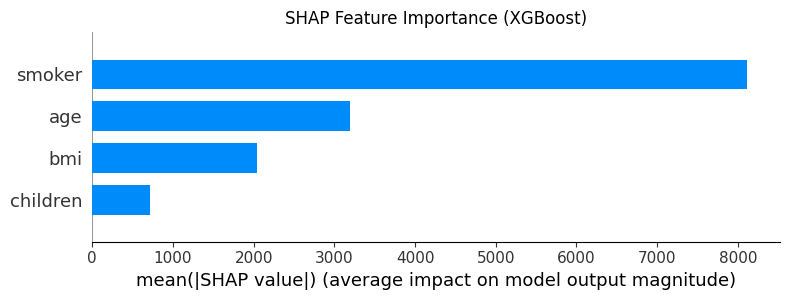

In [ ]:
# SHAP Summary Plot Global Importance
shap.summary_plot(shap_values_xgb, xtest_f, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

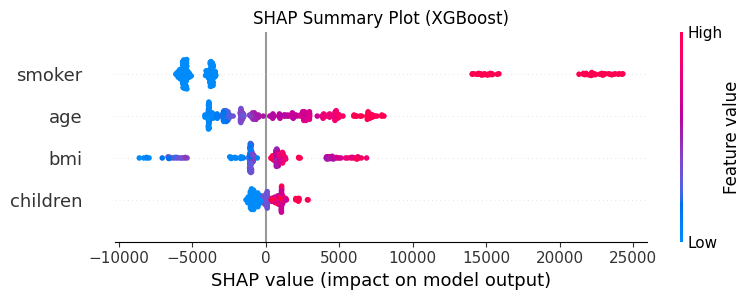

In [64]:
# SHAP Summary Plot Beeswarm for Distribution and Impact
shap.summary_plot(shap_values_xgb, xtest_f, show=False)
plt.title('SHAP Summary Plot (XGBoost)')
plt.tight_layout()
plt.show()


Smoker status has the largest impact on insurance costs                                  
High BMI values increase costs                              
Older age leads to higher premiums                            
Number of children has minimal effect                         

In [66]:
# Comparing SHAP vs XGBoost built-in importance
shap_importance = shap_values_xgb.abs.mean(0).values
xgb_importance = finalmodel.feature_importances_

comparison = pd.DataFrame({
    'Feature': xtest_f.columns,
    'SHAP Importance': shap_importance,
    'XGBoost Importance': xgb_importance
}).sort_values('SHAP Importance', ascending=False)

print(comparison)

    Feature  SHAP Importance  XGBoost Importance
3    smoker      8116.411734            0.854036
0       age      3192.521105            0.041658
1       bmi      2037.673582            0.092950
2  children       721.717632            0.011355


Champion Model Deployment

In [70]:
# Saving the final model
with open('insurancemodelf.pkl', 'wb') as file:
    pickle.dump(finalmodel, file)

print("Model saved successfully as 'insurancemodelf.pkl'")

Model saved successfully as 'insurancemodelf.pkl'


In [71]:
# Testing prediction with new data
new_data = pd.DataFrame({
    'age': [60],
    'bmi': [23.9],
    'children': [4],
    'smoker': [1]
})

prediction = finalmodel.predict(new_data)[0]
print(f"Test Prediction:")
print(f"Input: Age=60, BMI=23.9, Children=4, Smoker=Yes")
print(f"Predicted Insurance Cost: ${prediction:,.2f}")

Test Prediction:
Input: Age=60, BMI=23.9, Children=4, Smoker=Yes
Predicted Insurance Cost: $29,505.65
